```bash
=============================================================================  
STAGE 1 — AIR MODELLING ATTRIBUTION  
Gaussian Plume Transport Matrix → Classical & Bayesian Source Inversion  
Model: C = T · Q  
  C  (n_stations,)       — observed concentration vector  [µg/m³]  
  T  (n_stations, n_src) — transport matrix (Gaussian Plume)  [µg/m³ per g/s]  
  Q  (n_src,)            — unknown emission rates  [g/s]  
References:  
  Seinfeld & Pandis, "Atmospheric Chemistry and Physics", 3rd ed., 2016  
  Pasquill & Smith, "Atmospheric Diffusion", 3rd ed., 1983  
  Turner, "Workbook of Atmospheric Dispersion Estimates", EPA, 1970  
=============================================================================  
```

In [ ]:
# # ! ipynb-py-convert 1_tp_matrix.ipynb 1_tp_matrix.py
# import matplotlib.pyplot as plt
# import scienceplots
# plt.style.use(['science','no-latex'])

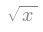

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sympy import (
    symbols,
    exp,
    pi,
    sqrt,
    latex,
    simplify,
    cos,
    sin,
    atan2,
    init_printing,
)
from IPython.display import display, Math
from tqdm import tqdm
from collections import Counter
from sympy import Mod, asin
import networkx as nx
import math
import arviz as az
import pymc as pm
from sympy import log
from scipy.optimize import nnls
from scipy.linalg import lstsq, svd

# Display settings
init_printing()
pd.set_option("display.float_format", "{:.4f}".format)
np.set_printoptions(
    linewidth=140,
)
x = symbols("x")
sqrt(x)

In [4]:
from IPython.display import display

POLLUTANT = "pm25"  # change to pm10, no2, etc. to explore
H_STACK = 20.0  # effective stack / emission height [m]
# 20 m is a reasonable proxy for a monitoring station
# in a mixed urban environment (road + industry blend)
ROOT_DIR = Path().resolve().parents[2]
DATA_DIR = ROOT_DIR / "backend" / "data"
MASTER_DATASET_FILE = DATA_DIR / "artifacts" / "final_master_dataset.csv"
STATIONS_FILE = DATA_DIR / "raw" / "stations.csv"
stations_df = pd.read_csv(STATIONS_FILE)
display(stations_df.head(5))
STATION_NAMES = stations_df["station_name"].unique().tolist()
print("Station names:\n",STATION_NAMES)

,slNo,station_name,organization,latitude,longitude,site_id
0,1,BTMLayout,CPCB,12.9135,77.5951,162
1,2,BWSSBKadabesanahalli,CPCB,12.9352,77.6814,164
2,3,BapujiNagar,KSPCB,12.9519,77.5398,1553
3,4,CityRailwayStation,KSPCB,12.9757,77.5661,165
4,5,Hebbal,KSPCB,13.0292,77.5859,1554


Station names:
 ['BTMLayout', 'BWSSBKadabesanahalli', 'BapujiNagar', 'CityRailwayStation', 'Hebbal', 'HombegowdaNagar', 'Jayanagar5thBlock', 'Jigani', 'KasturiNagar', 'Peenya', 'RvceMailasandra', 'SaneguravaHalli', 'ShivapuraPeenya', 'SilkBoard']


In [5]:
# Block 1 — LOAD DATA (with graceful synthetic fallback)
N = len(STATION_NAMES)  # 14
df_full = pd.read_csv(MASTER_DATASET_FILE, parse_dates=["time"])
df_full = df_full[df_full["station_name"].isin(STATION_NAMES)]
display(df_full.head(3))
display(df_full.dtypes)
print(f"df.dtypes[{POLLUTANT}]",df_full.dtypes[POLLUTANT]) # Pandas Series object can be acessed like normal python dictionary

,time,pm25,pm10,no,no2,nox,nh3,so2,co,o3,...,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,station_name,site,org,latitude,longitude
0,2025-01-01 00:00:00,36.0000,90.0000,3.1000,11.8000,9.8000,5.0000,4.5000,500.0000,33.3000,...,114.0000,0.0000,0.0000,0.0000,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
1,2025-01-01 00:15:00,36.0000,90.0000,3.2000,12.4000,10.2000,5.3000,4.6000,480.0000,35.5000,...,112.0000,0.0000,0.0000,0.0000,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398
2,2025-01-01 00:30:00,36.0000,90.0000,3.2000,11.3000,9.6000,5.0000,4.7000,560.0000,33.6000,...,117.0000,0.0000,0.0000,0.0000,727.0000,BapujiNagar,1553,KSPCB,12.9519,77.5398


time                   datetime64[us]
pm25                          float64
pm10                          float64
no                            float64
no2                           float64
nox                           float64
nh3                           float64
so2                           float64
co                            float64
o3                            float64
benzene                       float64
toluene                       float64
average_temperature           float64
relative_humidity             float64
wind_speed                    float64
wind_direction                float64
rainfall                      float64
total_rainfall                float64
solar_radiation               float64
pressure                      float64
station_name                      str
site                            int64
org                               str
latitude                      float64
longitude                     float64
dtype: object

df.dtypes[pm25] float64


# 1. Select a specific timestamp

In [6]:
# Pick a representative single time window: median wind conditions per station
# then take the earliest time where all 14 stations have valid data

# 1. We Transpose the table at station_name (so station_names becomes columns)
before_rows = len(df_full)
filtered_df = df_full.dropna(
    subset=[
        POLLUTANT,
        "wind_speed",
        "wind_direction",
    ]  # Removes rows where any of these are missing
)
after_rows = len(filtered_df)
dropped_rows = before_rows - after_rows
print(f"1. Dropping rows which dont have [{POLLUTANT},wind_speed or wind_direction]")
print(f"{before_rows:,} - {after_rows:,}: {dropped_rows:,}")

# 2. First Pivot the table ar station_name
pivot_check = filtered_df.pivot_table(
    index="time", columns="station_name", values=POLLUTANT, aggfunc="first"
)
# pivot_check = pivot_check.reindex(columns=STATION_NAMES)
print(
    f"Pivoted table <Transposes the df by considering station_name as columns and {POLLUTANT} as row values > :"
)
display(pivot_check.head(3))

# 3. Keep times where at least 10 stations have data
print("2. Keep times with a minimum threshold of valid stations")
before_rows = len(pivot_check)
# thresh=10 means a row must have at least 10 non-NaN values to survive
full_rows = pivot_check.dropna(axis=0, thresh=12)
after_rows = len(full_rows)
print(f"Timestamps surviving threshold: {after_rows:,}")
print(f"{before_rows:,} - {after_rows:,}: {dropped_rows:,}")
display(pivot_check.head(3))

# 4. Select the most recent time (or any index as you wish)
if len(full_rows) > 0:
    t0 = full_rows.index[0]
else:
    t0 = filtered_df["time"].min()
print(f"Selected snapshot time: {t0}")

# 5. Select the C , WS , WD and SR for this particular timeperiod
snap = filtered_df[filtered_df["time"] == t0].set_index("station_name")
display(snap)
print(snap.shape)
C_obs_list = []
WS_list = []
WD_list = []
SR_list = []
for s in STATION_NAMES:
    if s in snap.index:
        C_obs_list.append(snap.loc[s, POLLUTANT])
        WS_list.append(snap.loc[s, "wind_speed"])
        WD_list.append(snap.loc[s, "wind_direction"])
        SR_list.append(snap.loc[s, "solar_radiation"])

    else:
        C_obs_list.append(np.nan)
        WS_list.append(np.nan)
        WD_list.append(np.nan)
        SR_list.append(np.nan)

# Convert to numpy arrays
C_obs = np.array(C_obs_list, dtype=float)
WS = np.array(WS_list, dtype=float)
WD = np.array(WD_list, dtype=float)
SR = np.array(SR_list, dtype=float)
hour = t0.hour

# Count NaNs before imputation
nan_counts = {
    "Pollutant (C_obs)": np.isnan(C_obs).sum(),
    "Wind Speed (WS)": np.isnan(WS).sum(),
    "Wind Direction (WD)": np.isnan(WD).sum(),
    "Solar Radiation (SR)": np.isnan(SR).sum(),
}

print("NaN Counts Before Imputation ")
for var_name, count in nan_counts.items():
    print(f"{var_name:<20}: {count} NaN(s) detected")

# Fill any remaining NaNs (Your existing code)
C_obs = np.where(np.isnan(C_obs), np.nanmedian(C_obs), C_obs)
WS = np.where(np.isnan(WS), np.nanmedian(WS), WS)
WD = np.where(np.isnan(WD), np.nanmedian(WD), WD)
SR = np.where(np.isnan(SR), np.nanmedian(SR), SR)


print(f"{'Stations':<20}: {N}")
print(f"{'Pollutant':<20}: {POLLUTANT}")
print(f"{'Wind speed range':<20}: {WS.min():.2f} - {WS.max():.2f} m/s")
print(f"{'Wind dir range':<20}: {WD.min():.1f}° - {WD.max():.1f}°")
display(filtered_df.isnull().sum())

1. Dropping rows which dont have [pm25,wind_speed or wind_direction]
420,480 - 315,360: 105,120
Pivoted table <Transposes the df by considering station_name as columns and pm25 as row values > :


station_name,BapujiNagar,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,,,
2025-01-01 00:00:00,36.0000,62.0000,61.0000,65.0000,71.1600,32.9900,1.0500,29.0000,57.0000
2025-01-01 00:15:00,36.0000,62.0000,61.0000,65.0000,71.1600,32.9900,1.0500,29.0000,57.0000
2025-01-01 00:30:00,36.0000,62.0000,61.0000,65.0000,71.1600,32.9900,0.9900,29.0000,57.0000


2. Keep times with a minimum threshold of valid stations
Timestamps surviving threshold: 0
35,040 - 0: 105,120


station_name,BapujiNagar,Hebbal,HombegowdaNagar,Jayanagar5thBlock,Jigani,KasturiNagar,RvceMailasandra,ShivapuraPeenya,SilkBoard
time,,,,,,,,,
2025-01-01 00:00:00,36.0000,62.0000,61.0000,65.0000,71.1600,32.9900,1.0500,29.0000,57.0000
2025-01-01 00:15:00,36.0000,62.0000,61.0000,65.0000,71.1600,32.9900,1.0500,29.0000,57.0000
2025-01-01 00:30:00,36.0000,62.0000,61.0000,65.0000,71.1600,32.9900,0.9900,29.0000,57.0000


Selected snapshot time: 2025-01-01 00:00:00


,time,pm25,pm10,no,no2,nox,nh3,so2,co,o3,...,wind_speed,wind_direction,rainfall,total_rainfall,solar_radiation,pressure,site,org,latitude,longitude
station_name,,,,,,,,,,,,,,,,,,,,,
BapujiNagar,2025-01-01,36.0000,90.0000,3.1000,11.8000,9.8000,5.0000,4.5000,500.0000,33.3000,...,0.0000,114.0000,0.0000,0.0000,0.0000,727.0000,1553,KSPCB,12.9519,77.5398
Hebbal,2025-01-01,62.0000,98.0000,0.0000,48.3000,0.0000,3.3000,12.6000,240.0000,5.4900,...,0.5000,97.0000,0.0000,0.0000,0.0000,0.0000,1554,KSPCB,13.0292,77.5859
HombegowdaNagar,2025-01-01,61.0000,101.0000,0.2000,9.9000,5.5000,6.0000,15.7000,510.0000,35.5700,...,0.0000,197.0000,0.0000,0.0000,0.0000,717.0000,1555,KSPCB,12.9385,77.5901
Jayanagar5thBlock,2025-01-01,65.0000,95.0000,1.6000,3.7000,4.5000,2.0000,6.5000,270.0000,15.4800,...,0.0000,156.0000,0.0000,0.0000,0.0000,718.0000,1556,KSPCB,12.9210,77.5849
Jigani,2025-01-01,71.1600,108.4500,4.2700,31.4700,35.6800,26.8400,11.6200,630.0000,23.3600,...,5.5000,114.6100,0.0000,0.0000,6.4300,996.6400,5729,KSPCB,12.7816,77.6299
KasturiNagar,2025-01-01,32.9900,42.9200,6.7000,23.8600,31.7600,24.9300,11.9700,460.0000,29.8900,...,1.5700,42.4900,0.0000,0.0000,10.4800,914.4900,5681,KSPCB,13.0039,77.6642
RvceMailasandra,2025-01-01,1.0500,69.3100,5.8100,31.1500,36.6300,16.0200,4.5600,700.0000,22.1600,...,2.3100,254.7200,0.0000,0.0000,0.0000,0.0000,5678,KSPCB,12.9214,77.5025
ShivapuraPeenya,2025-01-01,29.0000,121.5800,6.7300,12.4450,18.4950,10.6000,5.8350,1040.0000,25.6450,...,0.4600,78.1700,0.0000,0.0000,0.0000,939.4900,5686,KSPCB,13.0246,77.5080
SilkBoard,2025-01-01,57.0000,125.0000,1.2000,13.9000,8.3000,1.8000,10.3000,260.0000,19.9200,...,0.8000,125.0000,0.0000,0.0000,0.0000,719.0000,1558,KSPCB,12.9173,77.6228


(9, 24)
NaN Counts Before Imputation 
Pollutant (C_obs)   : 5 NaN(s) detected
Wind Speed (WS)     : 5 NaN(s) detected
Wind Direction (WD) : 5 NaN(s) detected
Solar Radiation (SR): 5 NaN(s) detected
Stations            : 14
Pollutant           : pm25
Wind speed range    : 0.00 - 5.50 m/s
Wind dir range      : 42.5° - 254.7°


time                   0
pm25                   0
pm10                   0
no                     0
no2                    0
nox                    0
nh3                    0
so2                    0
co                     0
o3                     0
benzene                0
toluene                0
average_temperature    0
relative_humidity      0
wind_speed             0
wind_direction         0
rainfall               0
total_rainfall         0
solar_radiation        0
pressure               0
station_name           0
site                   0
org                    0
latitude               0
longitude              0
dtype: int64

In [7]:
lats = np.array(stations_df.latitude)
lons = np.array(stations_df.longitude)
print("Latitude",lats)
print("Longitude",lons)

Latitude [12.9135218 12.9352049 12.951913  12.9756843 13.029152  12.938539  12.920984  12.7816279 13.003872  13.0270199 12.921418  12.990328
 13.0246342 12.917348 ]
Longitude [77.5950804 77.6814488 77.539784  77.5660749 77.585901  77.5901    77.584908  77.6299145 77.664217  77.494094  77.502466  77.5431385
 77.5080115 77.622813 ]


# 2. Symbolic rep - *Gaussian Plume Model*  

In [8]:
from IPython.display import display, Math
from sympy import symbols

# 2.1 Symbol definitions 
# Giving symbols proper LaTeX representations makes display() look professional
x, y, z, H, u = symbols("x y z H u", positive=True)
Q_src = symbols("Q", positive=True)  # emission rate [g/s]

sigma_y = symbols(r"\sigma_y", positive=True)
sigma_z = symbols(r"\sigma_z", positive=True)

a_y, b_y = symbols("a_y b_y", positive=True)
a_z, b_z = symbols("a_z b_z", positive=True)

# 2.2 Full 3-D Gaussian plume (with ground reflection)
C_full = (
    Q_src
    / (2 * pi * u * sigma_y * sigma_z)
    * exp(-(y**2) / (2 * sigma_y**2))
    * (
        exp(-((z - H) ** 2) / (2 * sigma_z**2))
        + exp(-((z + H) ** 2) / (2 * sigma_z**2))
    )
)

# Ground-level concentration (z = 0)
C_ground = simplify(C_full.subs(z, 0))

print("\n1. Concentration Fields ")
print("[Eq 1] Full 3-D Gaussian plume concentration field:")
display(Math(f"\\huge C(x,y,z) = {latex(C_full)}"))

print("\n[Eq 2] Ground-level (z=0) with perfect image-source reflection:")
display(Math(f"\\huge C(x,y,0) = {latex(C_ground)}"))


# 2.3 Transport coefficient T = C/Q
T_sym = simplify(C_ground / Q_src)

print("\n2. Transport Coefficient ")
print("[Eq 3] Transport coefficient T(x,y) where C = T * Q (Unit: s/m³):")
display(Math(f"\\huge T(x,y) = {latex(T_sym)}"))


# 2.4 Pasquill-Gifford dispersion parameterisation -
sigma_y_eq = a_y * x**b_y
sigma_z_eq = a_z * x**b_z

print("\n3. Dispersion Parameterization ")
print("[Eq 4] Pasquill-Gifford power-law downwind equations:")
display(Math(f"\\huge \\sigma_y(x) = {latex(sigma_y_eq)}"))
display(Math(f"\\huge \\sigma_z(x) = {latex(sigma_z_eq)}"))

# CRITICAL IMPROVEMENT: Show the final combined equation explicitly!
T_final = T_sym.subs({sigma_y: sigma_y_eq, sigma_z: sigma_z_eq})
print("\n[Eq 5] Final fully-substituted analytical equation for T(x,y):")
display(Math(f"\\huge T(x,y) = {latex(simplify(T_final))}"))


# 2.5 Structured Coefficient Table
print("\n4. Atmospheric Stability Coefficients ")
print("Source: Pasquill (1961) & Turner EPA Workbook (1970)\n")

# 2.6 From Unstable (A) to Stable (F)
PG_COEFFS = {
    "A": dict(a_y=0.36, b_y=0.90, a_z=0.00023, b_z=2.10),
    "B": dict(a_y=0.25, b_y=0.90, a_z=0.058, b_z=1.09),
    "C": dict(a_y=0.19, b_y=0.90, a_z=0.11, b_z=0.91),
    "D": dict(a_y=0.13, b_y=0.90, a_z=0.57, b_z=0.58),
    "E": dict(a_y=0.096, b_y=0.90, a_z=0.85, b_z=0.47),
    "F": dict(a_y=0.063, b_y=0.90, a_z=0.77, b_z=0.42),
}
# Clean tabular alignment using format string padding
header = (
    f"  {'Stability Class':<24} | {'a_y':<8} | {'b_y':<6} | {'a_z':<8} | {'b_z':<6}"
)
print(header)
print("  " + "-" * len(header))
for cls, v in PG_COEFFS.items():
    print(
        f"  {cls:<24} | {v['a_y']:8.4f} | {v['b_y']:6.2f} | {v['a_z']:8.5f} | {v['b_z']:6.2f}"
    )


1. Concentration Fields 
[Eq 1] Full 3-D Gaussian plume concentration field:


<IPython.core.display.Math object>


[Eq 2] Ground-level (z=0) with perfect image-source reflection:


<IPython.core.display.Math object>


2. Transport Coefficient 
[Eq 3] Transport coefficient T(x,y) where C = T * Q (Unit: s/m³):


...

<IPython.core.display.Math object>

<IPython.core.display.Math object>


[Eq 5] Final fully-substituted analytical equation for T(x,y):


<IPython.core.display.Math object>


4. Atmospheric Stability Coefficients 
Source: Pasquill (1961) & Turner EPA Workbook (1970)

  Stability Class          | a_y      | b_y    | a_z      | b_z   
  ------------------------------------------------------------------
  A                        |   0.3600 |   0.90 |  0.00023 |   2.10
  B                        |   0.2500 |   0.90 |  0.05800 |   1.09
  C                        |   0.1900 |   0.90 |  0.11000 |   0.91
  D                        |   0.1300 |   0.90 |  0.57000 |   0.58
  E                        |   0.0960 |   0.90 |  0.85000 |   0.47
  F                        |   0.0630 |   0.90 |  0.77000 |   0.42


In [9]:
# Block 3 — NUMERICAL HELPERS (haversine, bearing, stability, σ, T element)
# look into bearing.html and visualize.html
from sympy import Mod, asin

# Physical thresholds — tunable constants, not magic numbers
MIN_WIND_SPEED_MS = 0.5  # [m/s]  calm-wind threshold; below this the plume equation breaks down physically (Pasquill-Gifford is only valid u ≥ 0.5)
MIN_DOWNWIND_DIST_M = 500.0  # [m]    near-field threshold; PG power-law was calibrated on field data at x ≥ 500 m. Extrapolating closer produces unphysically high (→ inf) transport coefficients.
MAX_SIGMA_Z_M = 500.0  # [m]    cap to prevent vertical dilution ≈ 0 for extremely stable / long-range runs

# Symbol definitions
R = symbols("R", positive=True)
lat1, lon1, lat2, lon2 = symbols("lat1 lon1 lat2 lon2", real=True)
phi1, phi2 = symbols("phi_1 phi_2", real=True)
Delta_phi = symbols(r"\Delta\phi", real=True)
Delta_lambda = symbols(r"\Delta\lambda", real=True)

# Haversine Formula
a_expr = sin(Delta_phi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(Delta_lambda / 2) ** 2
d_expr = 2 * R * asin(sqrt(a_expr))

print("\n[Eq 1] Haversine intermediate term:\n")
display(Math(f"\\huge a = {latex(a_expr)}"))
print("\n[Eq 2] Great-circle distance:\n")
display(Math(f"\\huge d = {latex(d_expr)}"))


def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between two points on Earth.
    Formula (Sinnott, 1984):
        a = sin²(Δlat/2) + cos(lat1)·cos(lat2)·sin²(Δlon/2)
        d = 2R · arcsin(√a)
    where R = 6371 km (mean Earth radius).
    """
    R = 6371.0
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δφ = np.radians(lat2 - lat1)
    Δλ = np.radians(lon2 - lon1)
    a = np.sin(Δφ / 2) ** 2 + np.cos(φ1) * np.cos(φ2) * np.sin(Δλ / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def bearing_deg(lat1, lon1, lat2, lon2):
    """Look into bearing.html for more detailed understanding"""
    """
    Initial bearing from (lat1,lon1) to (lat2,lon2), measured clockwise from North.
    Formula:
        θ = atan2(sin(Δλ)·cos(φ2),  cos(φ1)·sin(φ2) - sin(φ1)·cos(φ2)·cos(Δλ))
        θ_deg = (θ_rad x 180/π) mod 360
    """
    φ1, φ2 = np.radians(lat1), np.radians(lat2)
    Δλ = np.radians(lon2 - lon1)
    θ = np.arctan2(
        np.sin(Δλ) * np.cos(φ2),
        np.cos(φ1) * np.sin(φ2) - np.sin(φ1) * np.cos(φ2) * np.cos(Δλ),
    )
    return np.degrees(θ) % 360


# Bearing Formula
theta_expr = atan2(
    sin(Delta_lambda) * cos(phi2),
    cos(phi1) * sin(phi2) - sin(phi1) * cos(phi2) * cos(Delta_lambda),
)
theta_deg_expr = Mod(180 * theta_expr / pi, 360)

print("\n[Eq 3] Initial bearing in radians:\n")
display(Math(f"\\huge \\theta = {latex(theta_expr)}"))
print("\n[Eq 4] Initial bearing in degrees:\n")
display(Math(f"\\huge \\theta_{{deg}} = {latex(theta_deg_expr)}"))


def stability_class(wind_speed_ms, solar_rad_Wm2, is_daytime):
    """
    Pasquill stability class (A-F) from wind speed, solar radiation and time.
    Simplified Pasquill-Gifford lookup (Turner, 1970).
    Returns: one of 'A','B','C','D','E','F'
    """
    u = wind_speed_ms
    sr = solar_rad_Wm2
    if is_daytime:
        if u < 2:
            return "A" if sr > 600 else ("B" if sr > 300 else "C")
        elif u < 3:
            return "B" if sr > 300 else "C"
        elif u < 5:
            return "C" if sr > 50 else "D"
        else:
            return "D"
    else:  # night-time
        if u < 2:
            return "F"
        elif u < 3:
            return "E"
        else:
            return "D"


def sigma_y_z(x_m, cls):
    """
    Pasquill-Gifford dispersion coefficients.
    sigma_y(x) = a_y · x^b_y   [m]
    sigma_z(x) = a_z · x^b_z   [m]  (capped at 500 m for numerical stability)
    """
    c = PG_COEFFS[cls]
    sy = c["a_y"] * x_m ** c["b_y"]
    sz = min(c["a_z"] * x_m ** c["b_z"], 500.0)
    return sy, sz


def transport_element(
    lat_src,
    lon_src,
    lat_rec,
    lon_rec,
    wind_speed_ms,
    wind_dir_deg,
    stability_cls,
    H_m=H_STACK,
):
    """
    Compute the scalar transport coefficient T_{i,j} from source j to receptor i.
    Steps:
      1. Haversine distance d [km] → d_m [m]
      2. Bearing from source to receptor (geographic)
      3. Decompose into downwind (x) and crosswind (y) distances
         x = d_m · cos(wind_dir - bearing)   # positive = downwind
         y = d_m · sin(wind_dir - bearing)   # lateral offset
      4. If x ≤ 0 → receptor is UPWIND → T = 0
      5. sigma_y, sigma_z from P-G table
      6. Apply ground-level Gaussian plume formula x 1e6 (g→µg)

    Returns:
        T [µg/m³ per g/s]
    """
    if not np.isfinite(wind_speed_ms) or not np.isfinite(wind_dir_deg):
        return 0.0

    # Sensors occasionally report 0.0 m/s (calm conditions).  That is a valid
    # meteorological reading but makes the Gaussian Plume formula singular.
    # A 0.5 m/s floor is the conventional lower bound for PG applicability.
    u = max(float(wind_speed_ms), MIN_WIND_SPEED_MS)

    # 1. Calculate the Haversine distance and convert to metres
    d_km = haversine_km(lat_src, lon_src, lat_rec, lon_rec)
    if d_km < 0.01:  # same station (diagonal): self-emission
        # Use a minimal distance of 100 m so formula is well-defined
        d_km = 0.1
    d_m = d_km * 1000.0
    bear = bearing_deg(lat_src, lon_src, lat_rec, lon_rec)

    # 2. Angle of receptor relative to wind direction
    # Positive x = downwind direction = wind blows FROM source TOWARD receptor
    delta_rad = np.radians(wind_dir_deg - bear)
    x_m = d_m * np.cos(delta_rad)
    y_m = d_m * np.sin(delta_rad)
    if x_m <= 0 or not np.isfinite(x_m) or not np.isfinite(y_m):
        return 0.0  # receptor is upwind of source; no contribution

    # 3. Find the standard deviations (Dispersion coefficients)
    sy, sz = sigma_y_z(x_m, stability_cls)
    if sy < 1e-6 or sz < 1e-6:
        return 0.0

    lateral = np.exp(-(y_m**2) / (2 * sy**2))
    vertical = np.exp(-(H_m**2) / (2 * sz**2))
    T_raw = (1.0 / (np.pi * u * sy * sz)) * lateral * vertical
    if not np.isfinite(T_raw):
        return 0.0

    return T_raw * 1e6  # µg·m⁻³ per g·s⁻¹



[Eq 1] Haversine intermediate term:



<IPython.core.display.Math object>


[Eq 2] Great-circle distance:



<IPython.core.display.Math object>


[Eq 3] Initial bearing in radians:



<IPython.core.display.Math object>


[Eq 4] Initial bearing in degrees:



<IPython.core.display.Math object>

# 3. Calculate the Transport Matrix - *for particular pollutant*

In [10]:
from tqdm import tqdm
from collections import Counter

# Use per-source wind (wind at the SOURCE station drives transport)
is_day = 6 <= hour <= 18
stab_per = [stability_class(WS[k], SR[k], is_day) for k in range(N)]

stab_mode = Counter(stab_per).most_common(1)[0][0]
T_matrix = np.zeros((N, N))
for j, src in tqdm(enumerate(STATION_NAMES), total=N, desc="Building T matrix"):
    for i, rec in enumerate(STATION_NAMES):
        T_matrix[i, j] = transport_element(
            lats[j],
            lons[j],
            lats[i],
            lons[i],
            WS[j],
            WD[j],  # wind AT the source
            stab_per[j],
            H_STACK,
        )
print(f"T matrix shape  : {T_matrix.shape}")
print(f"T min (non-zero): {T_matrix[T_matrix > 0].min():.4f}  µg/m³ per g/s")
print(f"T max           : {T_matrix.max():.4f}  µg/m³ per g/s")
print(f"Zero entries    : {(T_matrix == 0).sum()} / {N * N}  (upwind pairs)")
print("First 4x4 block of T (µg/m³ per g/s):")
df_T_peek = pd.DataFrame(
    T_matrix[:4, :4], index=STATION_NAMES[:4], columns=STATION_NAMES[:4]
)
print(df_T_peek.to_string())
print(f"\n C_obs ({POLLUTANT}) per station [µg/m³]:")
for i, s in enumerate(STATION_NAMES):
    print(f"{s:30s}: {C_obs[i]:7.2f}")

Building T matrix: 100%|██████████| 14/14 [00:00<00:00, 7212.90it/s]

T matrix shape  : (14, 14)
T min (non-zero): 0.0000  µg/m³ per g/s
T max           : 277.4665  µg/m³ per g/s
Zero entries    : 153 / 196  (upwind pairs)
First 4x4 block of T (µg/m³ per g/s):
                      BTMLayout  BWSSBKadabesanahalli  BapujiNagar  CityRailwayStation
BTMLayout                0.0000                0.0000       0.0000              0.0000
BWSSBKadabesanahalli     0.0000                0.0000       0.0000              0.1064
BapujiNagar              0.0000                0.0000       0.0000              0.0000
CityRailwayStation       0.0000                0.0000       0.0000              0.0000

 C_obs (pm25) per station [µg/m³]:
BTMLayout                     :   57.00
BWSSBKadabesanahalli          :   57.00
BapujiNagar                   :   36.00
CityRailwayStation            :   57.00
Hebbal                        :   62.00
HombegowdaNagar               :   61.00
Jayanagar5thBlock             :   65.00
Jigani                        :   71.16
KasturiNagar      

/tmp/ipykernel_19580/2864025109.py:78: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_19580/2864025109.py:78: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_19580/2864025109.py:78: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_19580/2864025109.py:79: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  fig1.savefig("fig1_T_matrix_and_map.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_19580/2864025109.py:79: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  fig1.savefig("fig1_T_matrix_and_map.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_19580/2864025109.py:79: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig1.savefig("fig1_T_matrix_and_map.png", dpi=150, bbox_inches="tight")


  Saved: fig1_T_matrix_and_map.png


/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


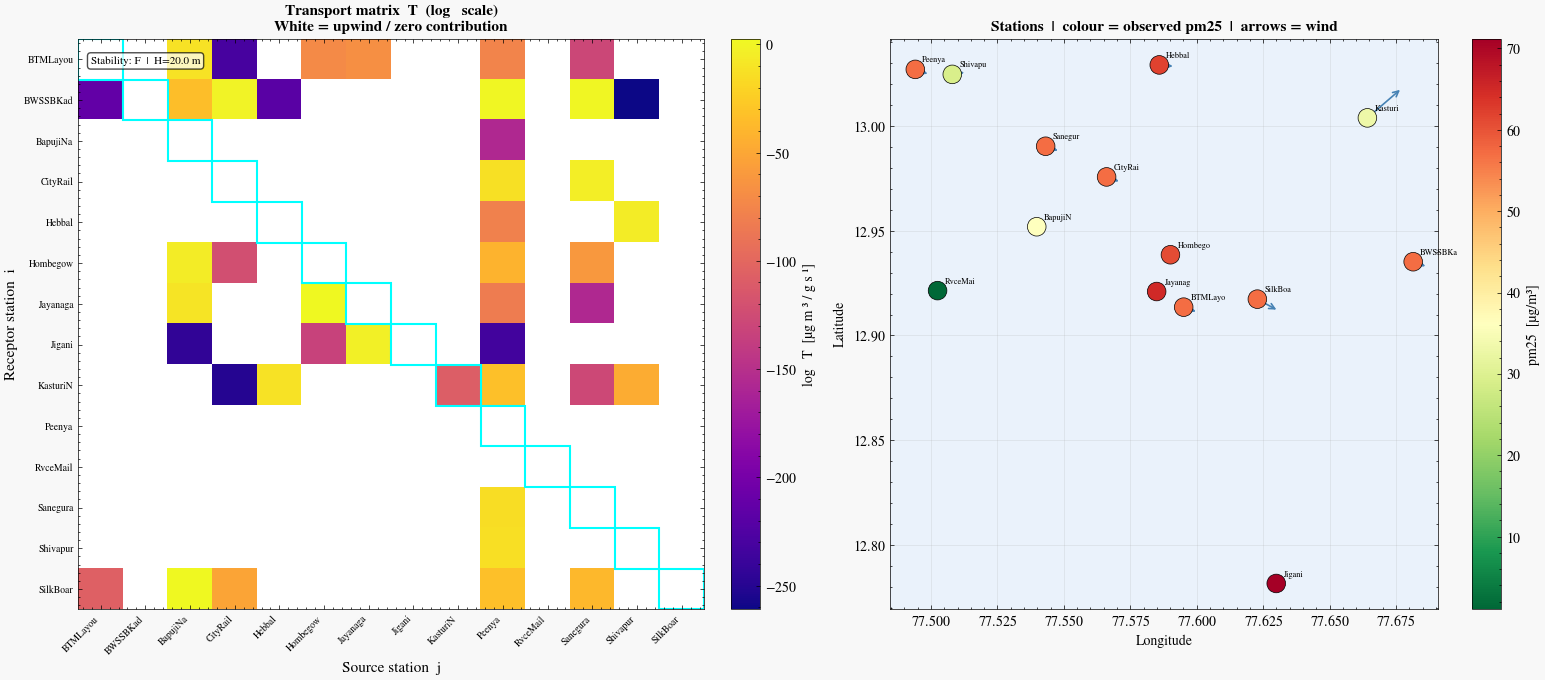

In [11]:
# Block 5 — FIGURE 1 : Transport matrix heatmap + station map
fig1, axes = plt.subplots(1, 2, figsize=(16, 7))
fig1.patch.set_facecolor("#f8f8f8")

# Left: T matrix heatmap
ax = axes[0]
T_log = np.log10(np.where(T_matrix > 0, T_matrix, np.nan))
im = ax.imshow(T_log, cmap="plasma", aspect="auto")
cbar = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log₁₀ T  [µg m⁻³ / g s⁻¹]", fontsize=10)

short = [s[:8] for s in STATION_NAMES]
ax.set_xticks(range(N))
ax.set_xticklabels(short, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(N))
ax.set_yticklabels(short, fontsize=7)
ax.set_xlabel("Source station  j", fontsize=11)
ax.set_ylabel("Receptor station  i", fontsize=11)
ax.set_title(
    "Transport matrix  T  (log₁₀ scale)\nWhite = upwind / zero contribution",
    fontsize=11,
    fontweight="bold",
)
# Annotate diagonal
for k in range(N):
    ax.add_patch(
        plt.Rectangle((k - 0.5, k - 0.5), 1, 1, fill=False, edgecolor="cyan", lw=1.5)
    )
ax.text(
    0.02,
    0.97,
    f"Stability: {stab_mode}  |  H={H_STACK} m",
    transform=ax.transAxes,
    fontsize=8,
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
)
# Right: station map with wind arrows
ax2 = axes[1]
sc = ax2.scatter(
    lons,
    lats,
    c=C_obs,
    cmap="RdYlGn_r",
    s=180,
    zorder=5,
    edgecolors="k",
    linewidths=0.5,
    norm=Normalize(vmin=C_obs.min(), vmax=C_obs.max()),
)
fig1.colorbar(sc, ax=ax2, label=f"{POLLUTANT}  [µg/m³]")
# Wind arrows (one per station, scaled by speed)
for k in range(N):
    wd_rad = np.radians(WD[k])
    dx = np.sin(wd_rad) * 0.012 * (WS[k] / WS.mean())
    dy = np.cos(wd_rad) * 0.012 * (WS[k] / WS.mean())
    ax2.annotate(
        "",
        xy=(lons[k] + dx, lats[k] + dy),
        xytext=(lons[k], lats[k]),
        arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.2),
    )

for k, s in enumerate(STATION_NAMES):
    ax2.annotate(
        s[:7], (lons[k], lats[k]), textcoords="offset points", xytext=(5, 5), fontsize=6
    )
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title(
    f"Stations  |  colour = observed {POLLUTANT}  |  arrows = wind",
    fontsize=11,
    fontweight="bold",
)
ax2.set_facecolor("#eaf2fb")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig1.savefig("fig1_T_matrix_and_map.png", dpi=150, bbox_inches="tight")
print("  Saved: fig1_T_matrix_and_map.png")
plt.show()


In [12]:
T_matrix = np.array(T_matrix)
np.set_printoptions(
    linewidth=140,
)
print(T_matrix)

[[0.00000000e+000 0.00000000e+000 4.54162926e-012 5.46842684e-231 0.00000000e+000 3.68522661e-072 9.71450085e-068 0.00000000e+000
  0.00000000e+000 8.73617518e-077 0.00000000e+000 7.46111934e-130 0.00000000e+000 0.00000000e+000]
 [1.60840422e-213 0.00000000e+000 1.49072770e-034 1.06388343e-001 8.65245931e-220 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 6.39451170e+000 0.00000000e+000 7.27164313e+000 1.09502855e-261 0.00000000e+000]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 2.33558229e-157 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
  0.00000000e+000 2.85681192e-013 0.00000000e+000 1.41932758e-004 0.00000000e+000 0.00000000e+000]
 [0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.

In [13]:
# Print wind directions to verify physical plausibility
print("Wind directions at stations:")
for i, s in enumerate(STATION_NAMES):
    print(f"{s:30s}: {WD[i]:6.1f}°")

Wind directions at stations:
BTMLayout                     :  114.6°
BWSSBKadabesanahalli          :  114.6°
BapujiNagar                   :  114.0°
CityRailwayStation            :  114.6°
Hebbal                        :   97.0°
HombegowdaNagar               :  197.0°
Jayanagar5thBlock             :  156.0°
Jigani                        :  114.6°
KasturiNagar                  :   42.5°
Peenya                        :  114.6°
RvceMailasandra               :  254.7°
SaneguravaHalli               :  114.6°
ShivapuraPeenya               :   78.2°
SilkBoard                     :  125.0°


# 4. Visualizing transport matrix - *as a Graph*

In [14]:
import networkx as nx

# Create directed graph of transport
G = nx.DiGraph()
for i, rec in enumerate(STATION_NAMES):
    for j, src in enumerate(STATION_NAMES):
        if i != j:
            G.add_edge(src, rec, weight=T_matrix[i, j])

print(f"Transport edges: {G.number_of_edges()}")

Transport edges: 182


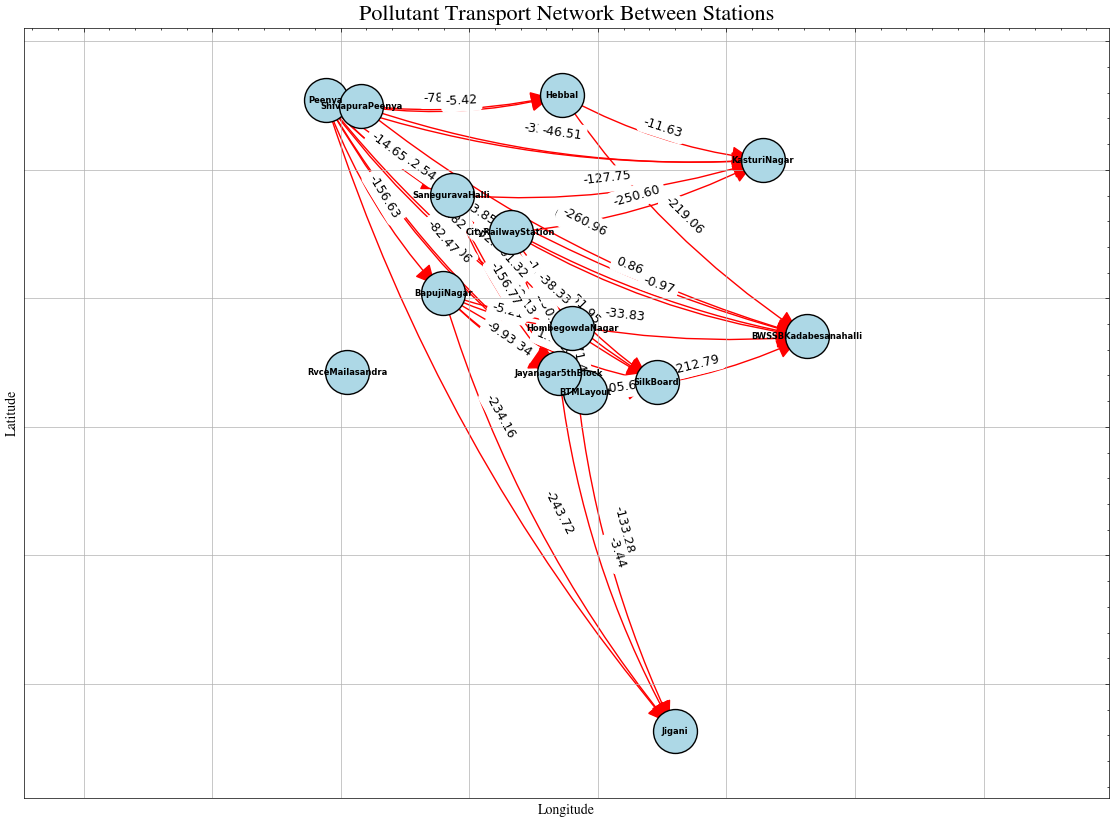

In [29]:
import matplotlib.pyplot as plt
import networkx as nx
import math

# Create position dictionary from lat/lon
pos = {}
for _, row in stations_df.iterrows():
    station = row["station_name"]
    # longitude -> x-axis
    # latitude  -> y-axis
    pos[station] = (row["longitude"], row["latitude"])

# Draw figure
plt.figure(figsize=(14, 10))
# Draw nodes
nx.draw_networkx_nodes(
    G, pos, node_size=1000, node_color="lightblue", edgecolors="black"
)
# Draw labels
nx.draw_networkx_labels(G, pos, font_size=6, font_weight="bold")
# Draw directed edges
red_edges = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] > 0]
dotted_edges = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] == 0]

# 2. Draw the active transport paths (Red, Solid)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=red_edges,
    edge_color="red",
    style="solid",
    arrows=True,
    arrowsize=30,
    width=1,
    connectionstyle="arc3,rad=0.1",
)

# # 3. Draw the zero-transport paths (Gray, Dotted)
# nx.draw_networkx_edges(
#     G,
#     pos,
#     edgelist=dotted_edges,
#     edge_color="gray",
#     style="dotted",
#     arrows=False,          # Turning off arrows for 0-weight makes it cleaner
#     width=1,
#     connectionstyle="arc3,rad=00.1",
# )
# Edge labels (transport weights) : Filter for weight > 0 and calculate log10(weight)
edge_labels = {
    (u, v): f"{math.log10(d['weight']):.2f}"
    for u, v, d in G.edges(data=True)
    if d["weight"] > 0
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

# Final formatting
plt.title("Pollutant Transport Network Between Stations", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.axis("equal")
plt.show()

# 5. Calulation using - *traditional methods*

In [16]:
from scipy.optimize import nnls
from scipy.linalg import lstsq, svd

In [17]:
# 7.1 Classic Least Squares
Q_true = None    
Q_lstsq, res_lstsq, rank_lstsq, sv_lstsq = lstsq(T_matrix, C_obs)
print("[Method 1]  scipy.linalg.lstsq  (minimum-norm least squares)")
print(T_matrix.shape)
print(f"Matrix rank: {rank_lstsq}")
print(f"Singular values range: {sv_lstsq.min():.4f} - {sv_lstsq.max():.4f}")
print(f"Condition number κ(T) = σ_max/σ_min = {sv_lstsq.max() / sv_lstsq.min():.2f}")
print(f"Negative Q entries: {(Q_lstsq < 0).sum()}  (physically invalid)")

[Method 1]  scipy.linalg.lstsq  (minimum-norm least squares)
(14, 14)
Matrix rank: 7
Singular values range: 0.0000 - 277.4665
Condition number κ(T) = σ_max/σ_min = inf
Negative Q entries: 3  (physically invalid)


/tmp/ipykernel_19580/3039963936.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Condition number κ(T) = σ_max/σ_min = {sv_lstsq.max() / sv_lstsq.min():.2f}")


In [18]:
#  7.2  Non-negative least squares
Q_nnls, res_nnls = nnls(T_matrix, C_obs)
print("[Method 2]  scipy.optimize.nnls  (non-negative constraint)")
print(f"Residual norm ||C - T·Q||: {res_nnls:.4f}")
print(f"Negative Q entries: {(Q_nnls < 0).sum()}  ✓")
print(f"Zero Q entries    : {(Q_nnls == 0).sum()}  (stations with no attribution)")

[Method 2]  scipy.optimize.nnls  (non-negative constraint)
Residual norm ||C - T·Q||: 137.3134
Negative Q entries: 0  ✓
Zero Q entries    : 8  (stations with no attribution)


In [19]:
#  7.3  Tikhonov regularisation
def tikhonov(T, C, lam):
    """
    Ridge-regularised inversion:
        Q̂ = (TᵀT + λI)⁻¹ Tᵀ C
    """
    n = T.shape[1]
    A = T.T @ T + lam * np.eye(n)
    b = T.T @ C
    return np.linalg.solve(A, b)


LAMBDA = 0.1  # regularisation strength; tune via L-curve or cross-validation
Q_tikh = tikhonov(T_matrix, C_obs, LAMBDA)
print(f"[Method 3]  Tikhonov regularisation  (λ = {LAMBDA})")
print(f"  ||C - T·Q||: {np.linalg.norm(C_obs - T_matrix @ Q_tikh):.4f}")
print(f"  Negative Q entries: {(Q_tikh < 0).sum()}")

[Method 3]  Tikhonov regularisation  (λ = 0.1)
  ||C - T·Q||: 169.8561
  Negative Q entries: 0


In [20]:
#  7.4  Truncated SVD
def truncated_svd_solve(T, C, n_components=None, thresh_ratio=1e-3):
    """
    Solve C = T·Q via pseudoinverse with small singular values zeroed out.
    thresh_ratio: singular values < thresh_ratio * σ_max are zeroed.
    """
    U, s, Vt = svd(T, full_matrices=False)
    thresh = thresh_ratio * s[0]
    s_inv = np.where(s > thresh, 1.0 / s, 0.0)
    return Vt.T @ (s_inv * (U.T @ C))


Q_svd = truncated_svd_solve(T_matrix, C_obs, thresh_ratio=1e-3)
print("[Method 4]  Truncated SVD  (threshold ratio = 1e-3)")
print(f"||C - T·Q||: {np.linalg.norm(C_obs - T_matrix @ Q_svd):.4f}")
print(f"Negative Q entries: {(Q_svd < 0).sum()}")

[Method 4]  Truncated SVD  (threshold ratio = 1e-3)
||C - T·Q||: 169.8562
Negative Q entries: 1


/tmp/ipykernel_19580/4277362020.py:9: RuntimeWarning: divide by zero encountered in divide
  s_inv = np.where(s > thresh, 1.0 / s, 0.0)


In [21]:
# For a 1D array, this prints each element formatted to 2 decimal places
print([f"{val:.2f}" for val in Q_lstsq])

['0.00', '0.00', '1.13', '-7595.83', '14230773564192.09', '0.23', '194729.42', '0.00', '0.00', '-456550.38', '-0.00', '401598.62', '16357947.97', '0.00']


In [22]:
#  7.5  Comparison table
methods = ["lstsq", "NNLS", "Tikhonov", "TruncSVD"]
Q_all = [Q_lstsq, Q_nnls, Q_tikh, Q_svd]

df_Q = pd.DataFrame({m: Q for m, Q in zip(methods, Q_all)}, index=STATION_NAMES)
df_Q["C_obs"] = C_obs
df_Q["C_lstsq"] = T_matrix @ Q_lstsq
df_Q["C_nnls"] = T_matrix @ Q_nnls
if Q_true is not None:
    df_Q["Q_true"] = Q_true

print("Inferred Q per station (g/s):")
display(df_Q)

print("Residuals  ||C - TQ||  per method:")
for m, Q in zip(methods, Q_all):
    r = np.linalg.norm(C_obs - T_matrix @ Q)
    print(f"{m:12s}: {r:.4f}")

Inferred Q per station (g/s):


,lstsq,NNLS,Tikhonov,TruncSVD,C_obs,C_lstsq,C_nnls
BTMLayout,0.0000,0.0000,0.0000,0.0000,57.0000,0.0000,0.0000
BWSSBKadabesanahalli,0.0029,0.0000,0.0000,0.0000,57.0000,56.9955,57.0011
BapujiNagar,1.1260,1.1260,1.1259,1.1260,36.0000,-0.0000,0.0000
CityRailwayStation,-7595.8327,0.0000,0.0639,0.0647,57.0000,57.0000,0.0011
Hebbal,14230773564192.0859,14230773564192.0293,0.0000,0.0000,62.0000,62.0000,62.0000
HombegowdaNagar,0.2343,0.2343,0.2343,0.2343,61.0000,0.0000,0.0000
Jayanagar5thBlock,194729.4228,194729.4228,0.2600,-0.0000,65.0000,65.0000,65.0000
Jigani,0.0039,0.0000,0.0000,0.0000,71.1600,71.1600,71.1600
KasturiNagar,0.0000,0.0000,0.0000,0.0000,32.9900,32.9900,32.9900
Peenya,-456550.3823,0.0000,3.8425,3.8867,57.0000,0.0000,0.0000


Residuals  ||C - TQ||  per method:
lstsq       : 124.9244
NNLS        : 137.3134
Tikhonov    : 169.8561
TruncSVD    : 169.8562


/tmp/ipykernel_19580/2732090549.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  f"κ(T) = {s_vals[0] / s_vals[-1]:.1f}",
/tmp/ipykernel_19580/2732090549.py:98: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_19580/2732090549.py:98: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  plt.tight_layout()
/tmp/ipykernel_19580/2732090549.py:99: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  fig2.savefig("fig2_classical_solvers.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_19580/2732090549.py:99: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  fig2.savefig("fig2_classical_solvers.png", dpi=150, bbox_inches="tight")


  Saved: fig2_classical_solvers.png


/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) STIXGeneral.
  fig.canvas.print_figure(bytes_io, **kw)


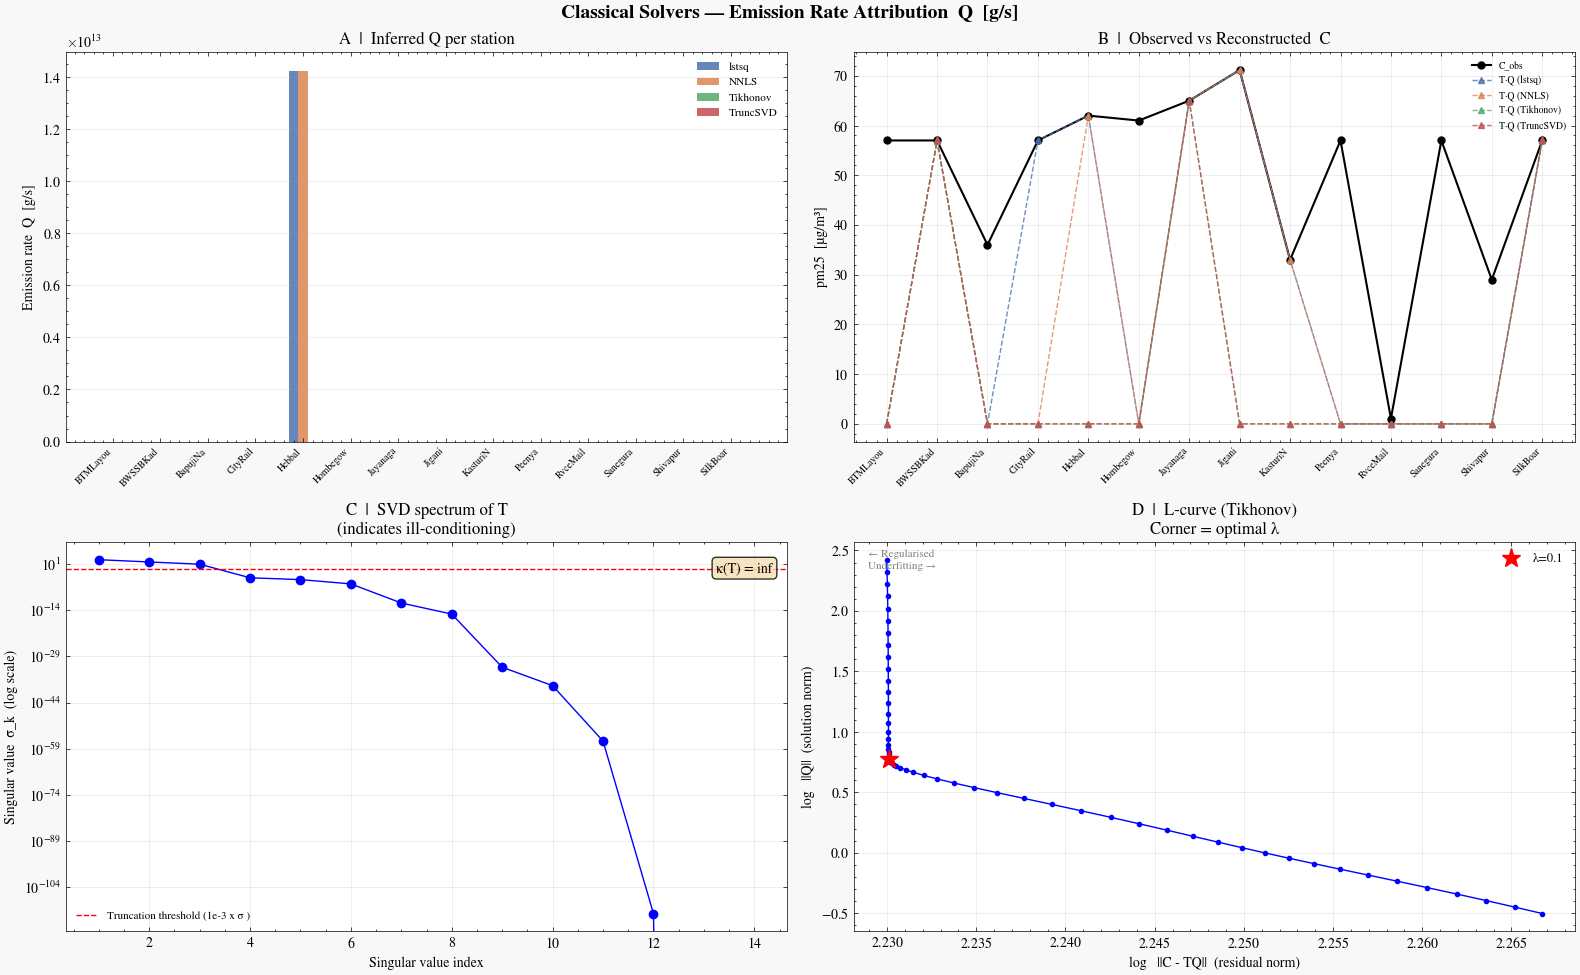

In [23]:
# Block 8 — FIGURE 2: Classical solver comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.patch.set_facecolor("#f8f8f8")
fig2.suptitle(
    "Classical Solvers — Emission Rate Attribution  Q  [g/s]",
    fontsize=14,
    fontweight="bold",
)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
x_ticks = np.arange(N)

# Panel A: Q per method
ax = axes2[0, 0]
width = 0.2
for k, (m, Q, col) in enumerate(zip(methods, Q_all, colors)):
    ax.bar(x_ticks + k * width, Q, width, label=m, color=col, alpha=0.85)
if Q_true is not None:
    ax.step(
        x_ticks + 0.3,
        Q_true,
        where="mid",
        color="black",
        lw=2,
        linestyle="--",
        label="Q_true (synthetic)",
    )
ax.set_xticks(x_ticks + width)
ax.set_xticklabels([s[:8] for s in STATION_NAMES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Emission rate  Q  [g/s]")
ax.set_title("A  |  Inferred Q per station")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Panel B: Observed vs Reconstructed C
ax = axes2[0, 1]
ax.plot(C_obs, "ko-", label="C_obs", lw=1.5, ms=5)
for m, Q, col in zip(methods, Q_all, colors):
    ax.plot(T_matrix @ Q, "^--", color=col, label=f"T·Q ({m})", lw=1, ms=4, alpha=0.8)
ax.set_xticks(x_ticks)
ax.set_xticklabels([s[:8] for s in STATION_NAMES], rotation=45, ha="right", fontsize=7)
ax.set_ylabel(f"{POLLUTANT}  [µg/m³]")
ax.set_title("B  |  Observed vs Reconstructed  C")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel C: Singular value spectrum
ax = axes2[1, 0]
U, s_vals, Vt = svd(T_matrix)
ax.semilogy(range(1, len(s_vals) + 1), s_vals, "bo-", ms=6)
ax.axhline(
    s_vals[0] * 1e-3, color="red", ls="--", label="Truncation threshold (1e-3 x σ₁)"
)
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value  σ_k  (log scale)")
ax.set_title("C  |  SVD spectrum of T\n(indicates ill-conditioning)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.text(
    0.98,
    0.95,
    f"κ(T) = {s_vals[0] / s_vals[-1]:.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
)

# Panel D: L-curve (Tikhonov)
ax = axes2[1, 1]
lambdas = np.logspace(-4, 4, 80)
resid_n = []
sol_n = []
for lv in lambdas:
    Qv = tikhonov(T_matrix, C_obs, lv)
    resid_n.append(np.log10(np.linalg.norm(C_obs - T_matrix @ Qv) + 1e-12))
    sol_n.append(np.log10(np.linalg.norm(Qv) + 1e-12))

ax.plot(resid_n, sol_n, "b-o", ms=3, lw=1)
# Highlight λ = LAMBDA
best_idx = np.argmin(np.abs(np.array(lambdas) - LAMBDA))
ax.plot(resid_n[best_idx], sol_n[best_idx], "r*", ms=14, label=f"λ={LAMBDA}")
ax.set_xlabel("log₁₀ ||C - TQ||  (residual norm)")
ax.set_ylabel("log₁₀ ||Q||  (solution norm)")
ax.set_title("D  |  L-curve (Tikhonov)\nCorner = optimal λ")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.text(
    0.02,
    0.98,
    "← Regularised\nUnderfitting →",
    transform=ax.transAxes,
    va="top",
    fontsize=8,
    color="gray",
)

plt.tight_layout()
fig2.savefig("fig2_classical_solvers.png", dpi=150, bbox_inches="tight")
print("  Saved: fig2_classical_solvers.png")
plt.show()

In [24]:
from sympy import symbols, pi, exp, log, sqrt, latex

#  9.1 Symbol Definitions
Q_i = symbols("Q_i", positive=True)
mu_0 = symbols(r"\mu_0", real=True)  # Prior location parameter
sigma_prior = symbols(r"\sigma_0", positive=True)  # Prior scale parameter
sigma_obs = symbols(r"\sigma_C", positive=True)  # Observation error standard deviation
C_i, T_i = symbols("C_i T_i", positive=True)

#  9.2 Prior: Log-Normal Formulation
# Enforces the hard physical constraint Q_i > 0 naturally.
log_prior_expr = (
    -((log(Q_i) - mu_0) ** 2) / (2 * sigma_prior**2)
    - log(Q_i)
    - log(sigma_prior)
    - log(sqrt(2 * pi))
)

print("1. Prior Model Formulation ")
print("[Eq 11] Prior on emission rates — Log-Normal (Q_i > 0):")
display(Math(r"\huge Q_i \sim \text{LogNormal}(\mu_0, \sigma_0^2)"))
display(Math(f"\\huge \\ln p(Q_i) = {latex(log_prior_expr)}"))


#  9.3 Likelihood: Gaussian Observation Noise
log_lik_expr = (
    -((C_i - T_i * Q_i) ** 2) / (2 * sigma_obs**2) - log(sigma_obs) - log(sqrt(2 * pi))
)

print("2. Observation Likelihood ")
print("[Eq 12] Likelihood — Gaussian measurement error model:")
display(Math(r"\huge C_i \mid Q_i, T_i \sim \mathcal{N}(T_i Q_i, \sigma_C^2)"))
display(Math(rf"\huge \ln \mathcal{{L}}(C_i \mid Q_i) = {latex(log_lik_expr)}"))


#  9.4 Posterior Framework & Mechanics
log_posterior_unnormalized = (
    (log(Q_i) - mu_0) ** 2 / (2 * sigma_prior**2)
    + log(Q_i)
    + (C_i - T_i * Q_i) ** 2 / (2 * sigma_obs**2)
)

print("3. Bayesian Posterior Integration ")
print("[Eq 13] Unnormalized log-posterior expansion via Bayes' Theorem:")
display(Math(r"\huge \ln p(Q \mid C) \propto \ln p(C \mid Q) + \ln p(Q)"))
display(
    Math(
        f"\\huge \\ln p(Q_i \mid C_i) \propto - \\left[ {latex(log_posterior_unnormalized)} \\right]"
    )
)

print(
    "\n> 💡 Note: Combining a Gaussian Likelihood with a Log-Normal Prior destroys conjugacy.\n" \
    "The posterior lacks a closed-form analytical solution. \n" \
    "We implement Markov Chain Monte Carlo (MCMC via NUTS in PyMC) to sample the field.\n"
)

#  9.5 Core Advantages Summary
print("4. Strategic Advantages of the Bayesian Framework ")
print("[Eq 14] Operational Benefits over Classical Inversion:")
print(
    "• Full Posterior Quantile Bounds : Yields exact uncertainty intervals on every source estimation Q_i\n"
    "• Natural Regularization         : Physical boundary rules (Q > 0) are mathematically absolute\n"
    "• Domain Knowledge Integration   : Prior structures easily integrate known baseline emission inventories\n"
    "• Information-Theoretic Audits  : Allows model validation and cross-validation via WAIC / LOO-CV metrics\n"
)


1. Prior Model Formulation 
[Eq 11] Prior on emission rates — Log-Normal (Q_i > 0):


<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_19580/4114421468.py:48: SyntaxWarning: invalid escape sequence '\m'
  f"\\huge \\ln p(Q_i \mid C_i) \propto - \\left[ {latex(log_posterior_unnormalized)} \\right]"


<IPython.core.display.Math object>

<IPython.core.display.Math object>

2. Observation Likelihood 
[Eq 12] Likelihood — Gaussian measurement error model:


...

<IPython.core.display.Math object>

3. Bayesian Posterior Integration 
[Eq 13] Unnormalized log-posterior expansion via Bayes' Theorem:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


> 💡 Note: Combining a Gaussian Likelihood with a Log-Normal Prior destroys conjugacy.
The posterior lacks a closed-form analytical solution. 
We implement Markov Chain Monte Carlo (MCMC via NUTS in PyMC) to sample the field.

4. Strategic Advantages of the Bayesian Framework 
[Eq 14] Operational Benefits over Classical Inversion:
• Full Posterior Quantile Bounds : Yields exact uncertainty intervals on every source estimation Q_i
• Natural Regularization         : Physical boundary rules (Q > 0) are mathematically absolute
• Domain Knowledge Integration   : Prior structures easily integrate known baseline emission inventories
• Information-Theoretic Audits  : Allows model validation and cross-validation via WAIC / LOO-CV metrics



# 6. Calculation using - *Baysian Inference*

In [30]:
# Block 10 — BAYESIAN INFERENCE WITH PyMC
import pymc as pm
import pytensor.tensor as pt

# Normalise T and C to improve sampler geometry
# (PyMC samples more efficiently when variables are O(1))
T_scale = T_matrix.max()
C_scale = C_obs.max()
T_norm = T_matrix / T_scale
C_norm = C_obs / C_scale

print(f"T_scale = {T_scale:.4f}   C_scale = {C_scale:.4f}")

with pm.Model() as bayes_model:
    # Prior: HalfNormal enforces Q ≥ 0 without log-transform tricks
    # σ=2 → 95% prior mass in [0, ~3.9] emission units (after rescaling)
    Q_bayes = pm.HalfNormal("Q", sigma=2.0, shape=N)
    # Predicted concentrations (linear model)
    C_pred = pm.math.dot(T_norm, Q_bayes)
    # Observation noise
    sigma_obs_rv = pm.HalfNormal("sigma_obs", sigma=0.2)
    # Likelihood
    C_like = pm.Normal("C_obs", mu=C_pred, sigma=sigma_obs_rv, observed=C_norm)
    # Inference — NUTS sampler
    print("Sampling with NUTS (2 chains x 1500 draws, 500 tune steps)…")
    trace = pm.sample(
        1500,
        tune=500,
        chains=2,
        cores=1,
        target_accept=0.90,
        progressbar=True,
        return_inferencedata=True,
        random_seed=42,
    )
    map_estimate = pm.find_MAP()
print("Sampling complete.")

T_scale = 277.4665   C_scale = 71.1600
Sampling with NUTS (2 chains x 1500 draws, 500 tune steps)…


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]


Output()

Sampling 2 chains for 500 tune and 1_500 draw iterations (1_000 + 3_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Output()

Sampling complete.


In [31]:
# Rescale back to original units: Q_actual = Q_sampled * C_scale / T_scale
Q_posterior = trace.posterior["Q"].values  # shape: (chain, draw, N)
Q_rescaled = Q_posterior * (C_scale / T_scale)  # g/s (approximate)
print(Q_posterior.shape)

Q_mean = Q_rescaled.mean(axis=(0, 1))
Q_lo = np.percentile(Q_rescaled, 5, axis=(0, 1))
Q_hi = np.percentile(Q_rescaled, 95, axis=(0, 1))
Q_map = map_estimate["Q"] * (C_scale / T_scale)

print("Posterior Q  [rescaled, approximate g/s]:")
print(f"  {'Station':30s}  {'Mean':>8}  {'Map':>8}  {'5th':>8}  {'95th':>8}")
for i, s in enumerate(STATION_NAMES):
    print(f"  {s:30s}  {Q_mean[i]:8.4f}  {Q_map[i]:8.4f}  {Q_lo[i]:8.4f}  {Q_hi[i]:8.4f}")

(2, 1500, 14)
Posterior Q  [rescaled, approximate g/s]:
  Station                             Mean       Map       5th      95th
  BTMLayout                         0.4044    0.0004    0.0373    0.9913
  BWSSBKadabesanahalli              0.3988    0.0004    0.0233    0.9952
  BapujiNagar                       0.4914    0.3411    0.0494    1.0637
  CityRailwayStation                0.4120    0.0004    0.0277    1.0076
  Hebbal                            0.4099    0.0004    0.0311    1.0191
  HombegowdaNagar                   0.2387    0.2176    0.0461    0.4510
  Jayanagar5thBlock                 0.4101    0.0004    0.0386    0.9722
  Jigani                            0.4173    0.0004    0.0387    1.0142
  KasturiNagar                      0.4051    0.0004    0.0339    0.9657
  Peenya                            0.4299    0.0607    0.0395    1.0523
  RvceMailasandra                   0.4080    0.0004    0.0311    1.0227
  SaneguravaHalli                   0.4217    0.0692    0.0345    1.

In [32]:
df_Q["Q_mean"] = Q_mean
df_Q["Q_lo"] = Q_lo
df_Q["Q_hi"] = Q_hi
df_Q["Q_map"] = Q_map
display(df_Q)

,lstsq,NNLS,Tikhonov,TruncSVD,C_obs,C_lstsq,C_nnls,Q_mean,Q_lo,Q_hi,Q_map
BTMLayout,0.0000,0.0000,0.0000,0.0000,57.0000,0.0000,0.0000,0.4044,0.0373,0.9913,0.0004
BWSSBKadabesanahalli,0.0029,0.0000,0.0000,0.0000,57.0000,56.9955,57.0011,0.3988,0.0233,0.9952,0.0004
BapujiNagar,1.1260,1.1260,1.1259,1.1260,36.0000,-0.0000,0.0000,0.4914,0.0494,1.0637,0.3411
CityRailwayStation,-7595.8327,0.0000,0.0639,0.0647,57.0000,57.0000,0.0011,0.4120,0.0277,1.0076,0.0004
Hebbal,14230773564192.0859,14230773564192.0293,0.0000,0.0000,62.0000,62.0000,62.0000,0.4099,0.0311,1.0191,0.0004
HombegowdaNagar,0.2343,0.2343,0.2343,0.2343,61.0000,0.0000,0.0000,0.2387,0.0461,0.4510,0.2176
Jayanagar5thBlock,194729.4228,194729.4228,0.2600,-0.0000,65.0000,65.0000,65.0000,0.4101,0.0386,0.9722,0.0004
Jigani,0.0039,0.0000,0.0000,0.0000,71.1600,71.1600,71.1600,0.4173,0.0387,1.0142,0.0004
KasturiNagar,0.0000,0.0000,0.0000,0.0000,32.9900,32.9900,32.9900,0.4051,0.0339,0.9657,0.0004
Peenya,-456550.3823,0.0000,3.8425,3.8867,57.0000,0.0000,0.0000,0.4299,0.0395,1.0523,0.0607


In [33]:
#  7.5  Comparison table
methods = ["lstsq", "NNLS", "Tikhonov", "TruncSVD", "BIMap", "BIMean", "BIlo", "BIhi"]
Q_all = [Q_lstsq, Q_nnls, Q_tikh, Q_svd, Q_map, Q_mean, Q_lo, Q_hi]

print("Residuals  ||C - TQ||  per method:")
for m, Q in zip(methods, Q_all):
    r = np.linalg.norm(C_obs - T_matrix @ Q)
    print(f"{m:12s}: {r:.4f}")

Residuals  ||C - TQ||  per method:
lstsq       : 124.9244
NNLS        : 137.3134
Tikhonov    : 169.8561
TruncSVD    : 169.8562
BIMap       : 183.3015
BIMean      : 180.2772
BIlo        : 194.2619
BIhi        : 185.1846


  Saved: fig3_bayesian_posterior.png


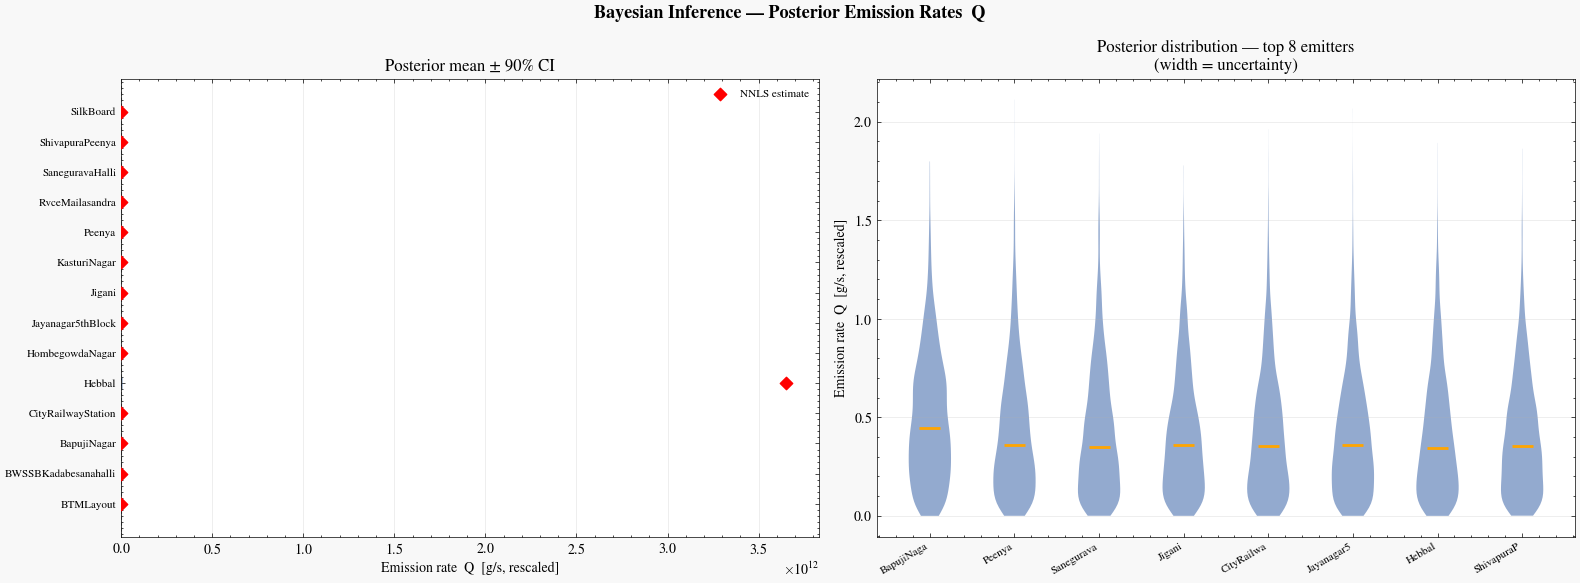

In [34]:
# Block 12 — FIGURE 3 : Bayesian posterior
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor("#f8f8f8")
fig3.suptitle(
    "Bayesian Inference — Posterior Emission Rates  Q", fontsize=13, fontweight="bold"
)

# Left: Posterior mean + credible interval
ax = axes3[0]
y_pos = np.arange(N)
ax.barh(
    y_pos,
    Q_mean,
    xerr=[Q_mean - Q_lo, Q_hi - Q_mean],
    align="center",
    alpha=0.75,
    color="#4C72B0",
    error_kw=dict(elinewidth=1.5, capsize=4, ecolor="#2c4e80"),
)
if Q_nnls is not None:
    ax.scatter(
        Q_nnls * (C_scale / T_scale),
        y_pos,
        color="red",
        zorder=5,
        s=40,
        marker="D",
        label="NNLS estimate",
    )
if Q_true is not None:
    ax.scatter(Q_true, y_pos, color="black", zorder=6, s=40, marker="*", label="Q_true")
ax.set_yticks(y_pos)
ax.set_yticklabels(STATION_NAMES, fontsize=8)
ax.set_xlabel("Emission rate  Q  [g/s, rescaled]")
ax.set_title("Posterior mean ± 90% CI")
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.axvline(0, color="gray", lw=0.8, ls="--")

# Right: Posterior violin plots for top-8 stations
ax2 = axes3[1]
top8_idx = np.argsort(Q_mean)[-8:][::-1]
data_violin = [Q_rescaled[:, :, k].flatten() for k in top8_idx]
labels_v = [STATION_NAMES[k][:10] for k in top8_idx]
parts = ax2.violinplot(
    data_violin, positions=range(len(top8_idx)), showmedians=True, showextrema=False
)
for pc in parts["bodies"]:
    pc.set_facecolor("#4C72B0")
    pc.set_alpha(0.6)
parts["cmedians"].set_color("orange")
parts["cmedians"].set_linewidth(2)
ax2.set_xticks(range(len(top8_idx)))
ax2.set_xticklabels(labels_v, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Emission rate  Q  [g/s, rescaled]")
ax2.set_title("Posterior distribution — top 8 emitters\n(width = uncertainty)")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig3.savefig("fig3_bayesian_posterior.png", dpi=150, bbox_inches="tight")
print("  Saved: fig3_bayesian_posterior.png")
plt.show()


Figure 4 — Observed vs reconstructed concentrations
Saved: fig4_reconstruction_comparison.png


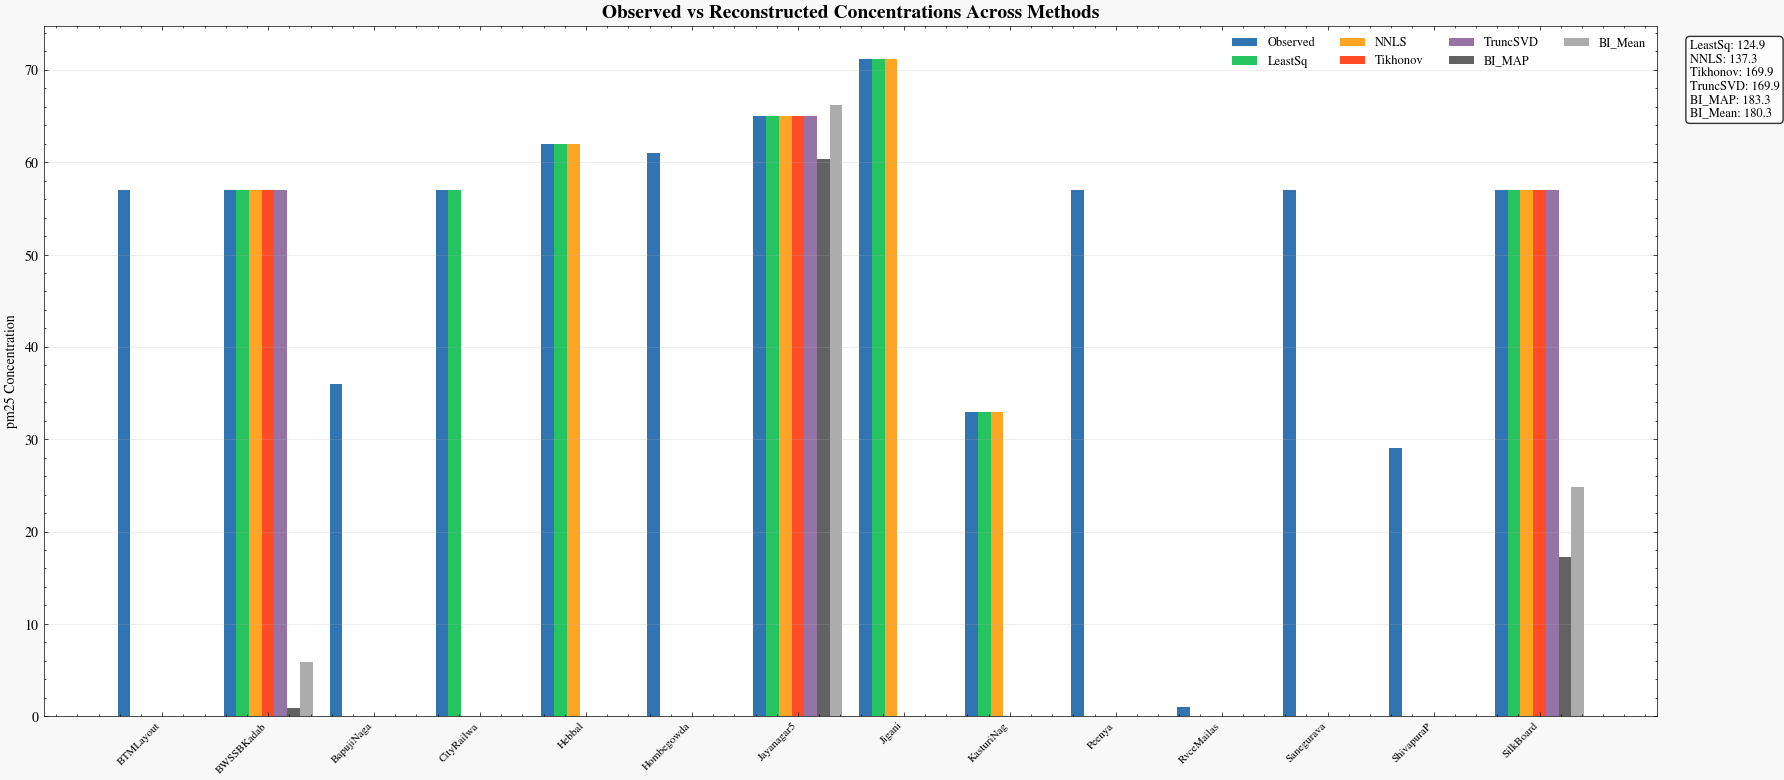

In [35]:
# Figure 4 — Reconstruction comparison
print("\nFigure 4 — Observed vs reconstructed concentrations")

# Compute reconstructed concentrations
C_reconstructed = {
    "Observed": C_obs,
    "LeastSq": T_matrix @ Q_lstsq,
    "NNLS": T_matrix @ Q_nnls,
    "Tikhonov": T_matrix @ Q_tikh,
    "TruncSVD": T_matrix @ Q_svd,
    "BI_MAP": T_matrix @ Q_map,
    "BI_Mean": T_matrix @ Q_mean,
}

# Figure setup
methods = list(C_reconstructed.keys())
n_methods = len(methods)
x = np.arange(N)
bar_width = 0.12
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor("#f8f8f8")

# Plot grouped bars
for k, method in enumerate(methods):
    vals = C_reconstructed[method]
    ax.bar(x + k * bar_width, vals, width=bar_width, label=method, alpha=0.85)
# Labels
ax.set_xticks(x + bar_width * (n_methods - 1) / 2)
ax.set_xticklabels([s[:10] for s in STATION_NAMES], rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"{POLLUTANT} Concentration")
ax.set_title(
    "Observed vs Reconstructed Concentrations Across Methods",
    fontsize=14,
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9, ncol=4)
# Residual annotations
residual_text = []
for method in methods[1:]:
    residual = np.linalg.norm(C_obs - C_reconstructed[method])
    residual_text.append(f"{method}: {residual:.1f}")

ax.text(
    1.02,
    0.98,
    "\n".join(residual_text),
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.savefig("fig4_reconstruction_comparison.png", dpi=150, bbox_inches="tight")
print("Saved: fig4_reconstruction_comparison.png")
plt.show()

Convergence criteria:
• R̂ (Gelman-Rubin) < 1.01  → chains have mixed
• ESS_bulk > 400           → sufficient effective samples
       ess_bulk  ess_tail r_hat mcse_mean mcse_sd
Q[0]       2150      1170  1.00     0.021   0.016
Q[1]       1719      1019  1.00     0.022    0.02
Q[2]       1645      1073  1.00     0.026   0.019
Q[3]       1636      1033  1.00     0.022   0.019
Q[4]       1699      1129  1.00     0.024    0.02
Q[5]       1380       779  1.00     0.011  0.0086
Q[6]       2230      1413  1.00      0.02   0.018
Q[7]       2083      1206  1.00     0.021   0.017
Q[8]       1830      1203  1.00     0.022   0.018
Q[9]       1365       904  1.00     0.025   0.022
Q[10]      1889      1338  1.00     0.023   0.018
Q[11]      2133      1272  1.00     0.022   0.018
Q[12]      2259      1242  1.00      0.02   0.017
Q[13]      2366      1503  1.00      0.02   0.018
Saved: fig5_trace.png


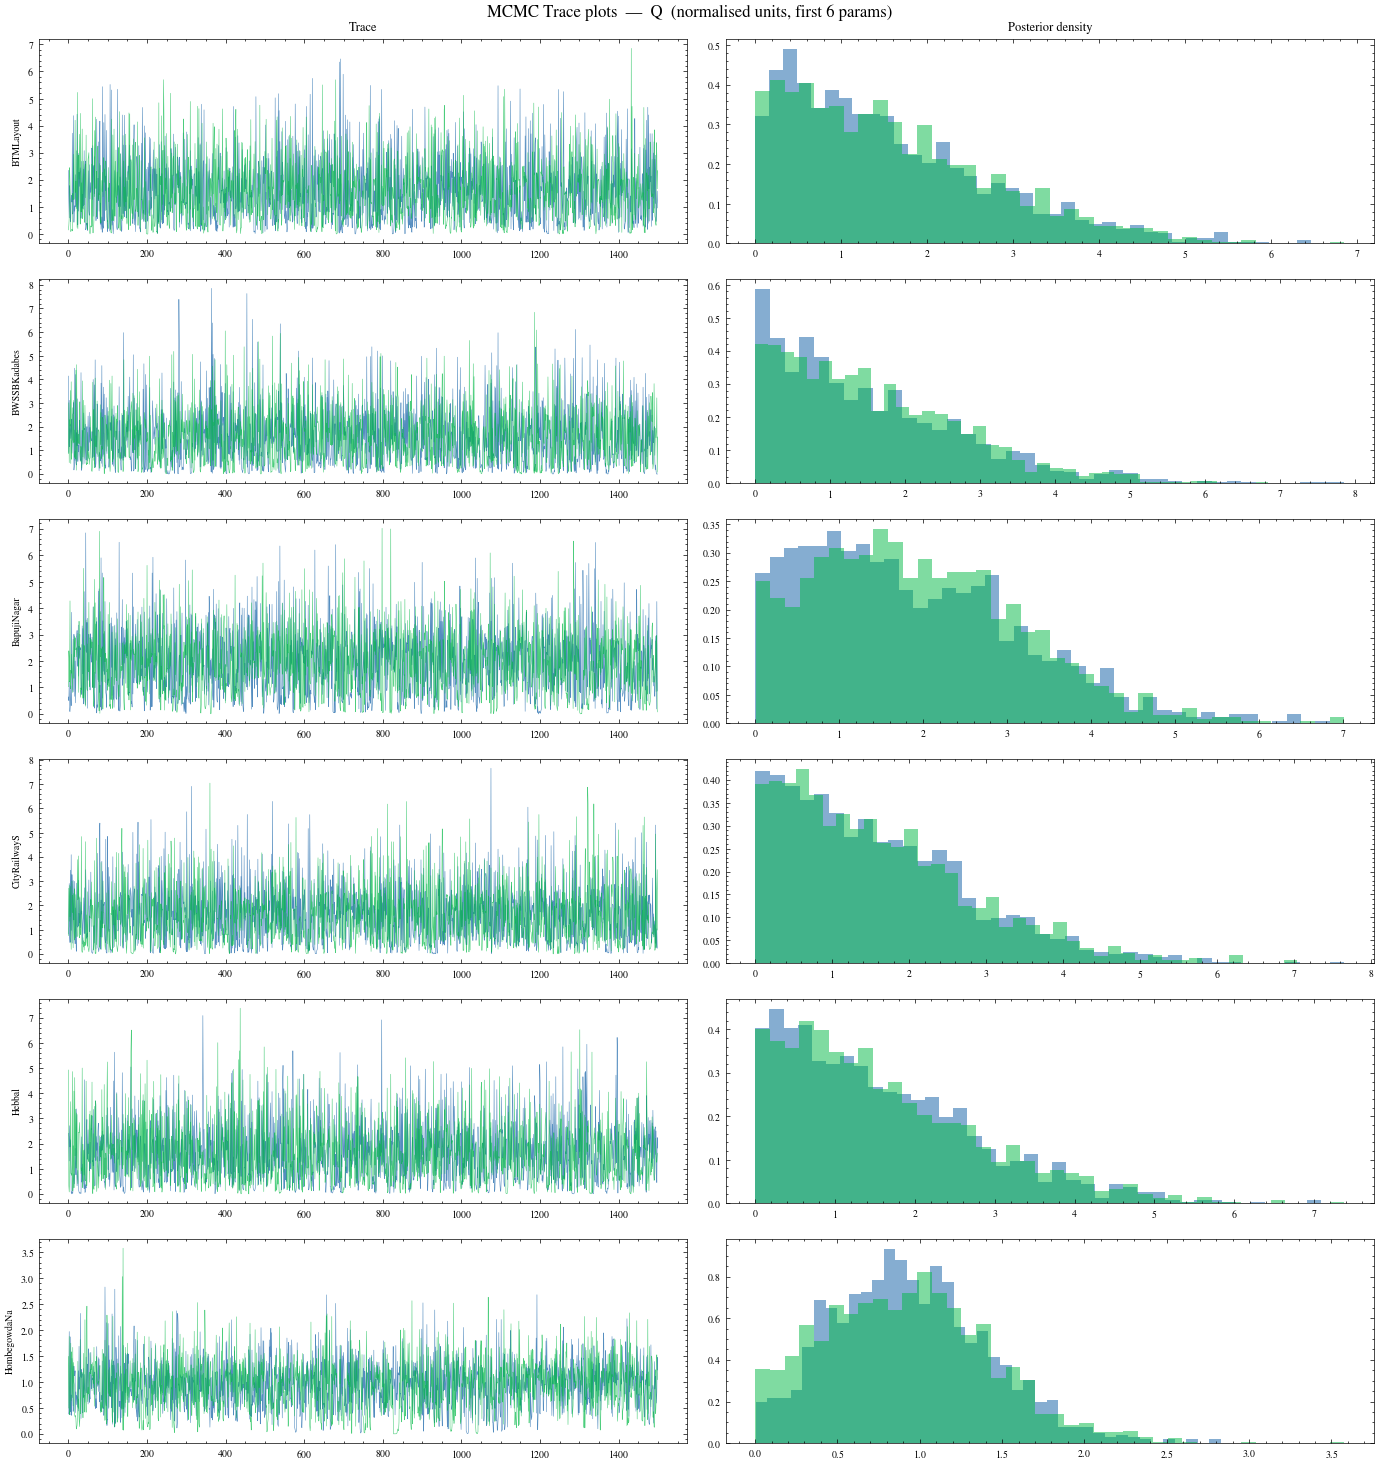

In [36]:
import arviz as az
# Block 14 — TRACE DIAGNOSTICS (R-hat, ESS)
print("Convergence criteria:")
print("• R̂ (Gelman-Rubin) < 1.01  → chains have mixed")
print("• ESS_bulk > 400           → sufficient effective samples")

diag = az.summary(trace, var_names=["Q"], kind="diagnostics")
print(diag.to_string())

# arviz >= 0.18 changed plot_trace API; use matplotlib directly
Q_post = trace.posterior["Q"].values  # (chain, draw, N)
n_show = min(6, N)
fig_trace, tr_axes = plt.subplots(n_show, 2, figsize=(14, 2.5 * n_show))
fig_trace.suptitle(
    "MCMC Trace plots  —  Q  (normalised units, first 6 params)", fontsize=12
)
for k in range(n_show):
    samples_k = Q_post[:, :, k]  # (chain, draw)
    # trace
    ax_t = tr_axes[k, 0]
    for ch in range(samples_k.shape[0]):
        ax_t.plot(samples_k[ch], lw=0.4, alpha=0.7)
    ax_t.set_ylabel(STATION_NAMES[k][:12], fontsize=7)
    ax_t.tick_params(labelsize=7)
    if k == 0:
        ax_t.set_title("Trace", fontsize=9)
    # density
    ax_d = tr_axes[k, 1]
    for ch in range(samples_k.shape[0]):
        ax_d.hist(samples_k[ch], bins=40, alpha=0.5, density=True)
    ax_d.tick_params(labelsize=7)
    if k == 0:
        ax_d.set_title("Posterior density", fontsize=9)
plt.tight_layout()
plt.savefig("fig5_trace.png", dpi=100, bbox_inches="tight")
print("Saved: fig5_trace.png")
plt.show()